In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import numpy as np
import util
import os
import time
import pprint
from math import ceil, floor
import matplotlib.pyplot as plt
import plotting as plotting
from solvers import SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from problem import State, Action, Request, ServiceWindow, PntSchedulingProblem
pp = pprint.PrettyPrinter()
figures_path = "../figures/AA229/"


# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Toy Problem

In [24]:
requests = [
    Request(id=0, usr_id=0, ts=0, te=10, dur=4),
    Request(id=1, usr_id=1, ts=0, te=10, dur=6),
    Request(id=2, usr_id=2, ts=0, te=10, dur=4),
]
N_req = len(requests)

service_windows = [
    # Dummy service window
    ServiceWindow(usr_id=0, sat_id=0, ts=0, te=5),
    ServiceWindow(usr_id=1, sat_id=0, ts=3, te=9),
    ServiceWindow(usr_id=2, sat_id=0, ts=0, te=3),
    ServiceWindow(usr_id=2, sat_id=0, ts=6, te=10),
    ServiceWindow(usr_id=0, sat_id=1, ts=3, te=7),
    ServiceWindow(usr_id=1, sat_id=1, ts=0, te=6),
]
N_win = len(service_windows)
N_sat = 2

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times = np.ones((N_sat, N_req, N_req))
for i in range(N_sat):
    transition_times[i, np.diag_indices(N_req)] = 0
transition_times[0, :] = 0
transition_times[:, 0] = 0
data_gen_func = lambda ts, te: -0.5 * (te - ts)
energy_gen_func = lambda ts, te: 0.5 * (te - ts)


time_step = 1
CN0 = np.ones((2, 3, 10 * time_step))

PntSchedulingProblem(
        t_step=Dt / pnt.SECS_PER_HOUR,
        t_final=tf / pnt.SECS_PER_HOUR,
        requests=requests,
        service_windows=service_windows,
        transition_times=transition_times,
        CN0=CN0,
        max_energy=max_energy,
        min_energy=min_energy,
        max_data=max_data,
        min_data=min_data,
        payload_data_gen=payload_data_gen,
        payload_energy_gen=payload_energy_gen,
        energy_gen=energy_gen,
        data_gen=data_gen,
    )

fig, ax = plt.subplots(1, 1, figsize=(6, 2))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)

NameError: name 'max_energy' is not defined

In [7]:
# Forward search
d = 6
gamma = 0.7
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

NameError: name 'problem' is not defined

Total reward: 10.16


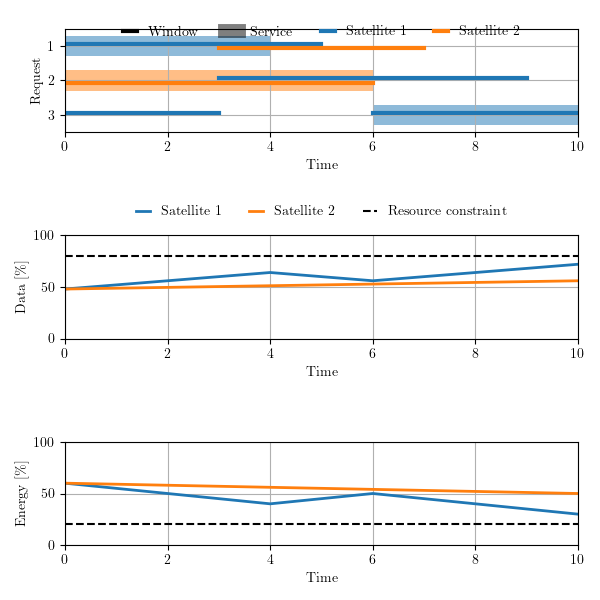

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

Solving MCTS (progress in hours):   0%|          | 0/10 [00:00<?, ?it/s]

Total reward: 12.64


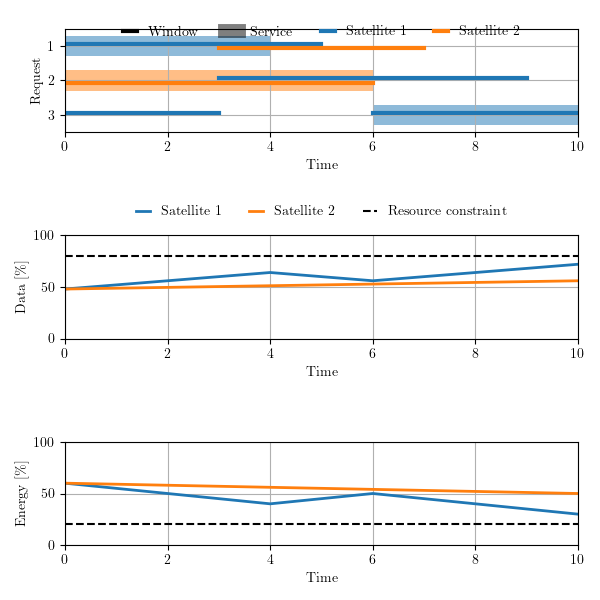

In [11]:
# MCTS
d = 5
gamma = 0.9
n = int(1e3)
c = 10
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, n=n, c=c)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Apr 04 02:23:38 PM: Your problem has 80 variables, 291 constraints, and 0 parameters.
(CVXPY) Apr 04 02:23:38 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 04 02:23:38 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 04 02:23:38 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 04 02:23:38 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Compiling problem (target solver=GUROBI).


(CVXPY) Apr 04 02:23:38 PM: Applying reduction QpMatStuffing
(CVXPY) Apr 04 02:23:38 PM: Applying reduction GUROBI
(CVXPY) Apr 04 02:23:38 PM: Finished problem compilation (took 6.473e-02 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Invoking solver GUROBI  to obtain a solution.
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-11
Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (mac64[arm] - Darwin 23.3.0 23D60)

CPU model: Apple M3 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 574 rows, 152 columns and 1848 nonzeros
Model fingerprint: 0x1f80aef1
Variable types: 72 continuous, 80 integer (80 binary)
Coefficient statistics:
  Mat

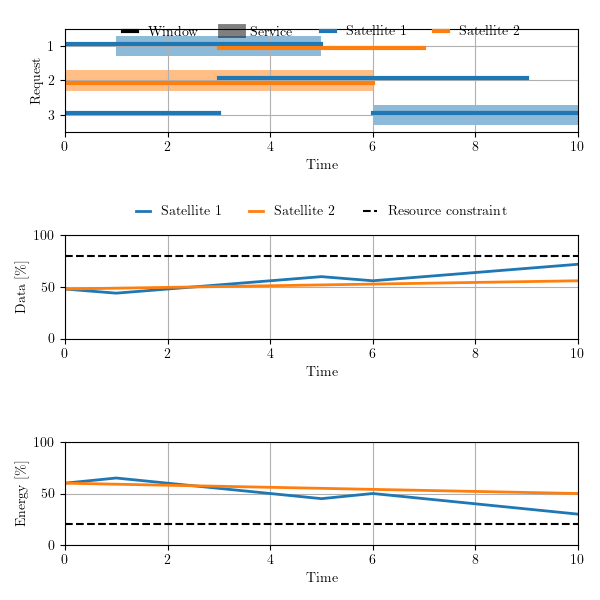

In [12]:
# IP
solver = DiscreteTimeIpSolver(problem)
policy = solver.solve(s, time_step_factor=1)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

# Experiment 1

## Users

In [2]:
import pathfinder_data

orbital_elements = pathfinder_data.orbital_elements.copy()
users = pathfinder_data.users.copy()
N_sat = 2

# Epoch (TAI)
epoch_0 = pnt.SpiceInterface.string_to_tai("2026/1/01 00:00:00.000 UTC")

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
coe_OP = np.zeros((N_sat, 6))
for i_sat in range(N_sat):
    coe_OP[i_sat, :] = orbital_elements
    coe_OP[i_sat, 2:] = np.deg2rad(coe_OP[i_sat, 2:])
coe_OP[i_sat, 5] += pnt.wrapToPi(coe_OP[i_sat, 5] + np.pi)
rv0_moon_sat_OP = pnt.classical_to_cartesian(coe_OP, pnt.MU_MOON)
rv0_moon_sat_mi = pnt.FrameConverter.convert(epoch_0, rv0_moon_sat_OP,pnt.MOON_OP, pnt.MOON_CI)

# Time
sma = coe_OP[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
tf = 1 * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = np.zeros((N_sat, N_t, 6))
rv_moon_sat_pa = np.zeros((N_sat, N_t, 6))
for i_sat in range(N_sat):
    rv_moon_sat_mi[i_sat] = dynamics.propagate(rv0_moon_sat_mi[i_sat], epoch_0, epochs)
    rv_moon_sat_pa[i_sat] = pnt.FrameConverter.convert(
        epochs, rv_moon_sat_mi[i_sat], pnt.MOON_CI, pnt.MOON_PA
    )
rv_moon_earth_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.EARTH)
rv_moon_earth_pa = pnt.FrameConverter.convert(epochs, rv_moon_earth_mi, pnt.MOON_CI, pnt.MOON_PA)
rv_moon_sun_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.SUN)
rv_moon_sun_pa = pnt.FrameConverter.convert(epochs, rv_moon_sun_mi, pnt.MOON_CI, pnt.MOON_PA)

# Attitude
r_sun = rv_moon_sun_mi[None, :, 0:3] - rv_moon_sat_mi[:, :, 0:3]
r_earth = rv_moon_earth_mi[None, :, 0:3] - rv_moon_sat_mi[:, :, 0:3]

e_sun = r_sun / np.linalg.norm(r_sun, axis=2)[:, :, None]
e_earth = r_earth / np.linalg.norm(r_earth, axis=2)[:, :, None]

r = rv_moon_sat_mi[:, :, 0:3]
v = rv_moon_sat_mi[:, :, 3:6]
r_norm = r / np.linalg.norm(r, axis=2)[:, :, None]
v_norm = v / np.linalg.norm(v, axis=2)[:, :, None]
e_nadir = -r_norm


def cross_norm(a, b):
    return np.cross(a, b) / np.linalg.norm(np.cross(a, b), axis=2)[:, :, None]


# Yaw-Steering (YS)
ez_ys = -r_norm
ey_ys = cross_norm(e_nadir, e_sun)
ex_ys = cross_norm(ey_ys, ez_ys)

In [3]:
def propagate_orbital_user(user: dict) -> np.array:
    """
    Propagate a user on orbit around the Moon.
    :param coe: [a, e, i, W, w, M] [km, -, deg, deg, deg, deg]
    :param frame: Frame
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    coe = user["orbital_elements"].copy()
    frame = user["frame"]
    coe[2:] = np.deg2rad(coe[2:])
    rv0 = pnt.classical_to_cartesian(coe, pnt.MU_MOON)
    rv0_mi = pnt.FrameConverter.convert(epoch_0, rv0, frame, pnt.MOON_CI)
    rv_mi = dynamics.propagate(rv0_mi, epoch_0, epochs)
    return rv_mi


def propagate_surface_user(user: dict) -> np.array:
    """
    Propagate a user on the surface of the Moon.
    :param lat_lon_alt: [lat, lon, alt] [deg, deg, km]
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    lat_lon_alt = user["location"].copy()
    lat_lon_alt[:2] = np.deg2rad(lat_lon_alt[:2])
    rv_pa = np.zeros((N_t, 6))
    rv_pa[:, :3] = pnt.geographical_to_cartesian(lat_lon_alt, pnt.R_MOON)
    return rv_pa


# Users
N_users = len(users)
user_type = np.array([user["type"] for user in users])
rv_moon_user_mi = np.zeros((N_users, N_t, 6))
rv_moon_user_pa = np.zeros((N_users, N_t, 6))
az_el_rho = np.zeros((N_sat, N_users, N_t, 3))

for i_usr, user in enumerate(users):
    if user["type"] == "orbital":
        rv_moon_user_mi[i_usr] = propagate_orbital_user(user)
        rv_moon_user_pa[i_usr] = pnt.FrameConverter.convert(
            epochs, rv_moon_user_mi[i_usr], pnt.MOON_CI, pnt.MOON_PA
        )
    elif user["type"] == "surface":
        rv_moon_user_pa[i_usr] = propagate_surface_user(user)
        rv_moon_user_mi[i_usr] = pnt.FrameConverter.convert(
            epochs, rv_moon_user_pa[i_usr], pnt.MOON_PA, pnt.MOON_CI
        )
    else:
        raise ValueError("Invalid user type")

    for j_sat in range(N_sat):
        az_el_rho[j_sat, i_usr] = pnt.cartesian_to_azimuth_elevation_range(
            rv_moon_user_mi[i_usr, :, :3], rv_moon_sat_mi[j_sat, :, :3]
        )

surface_elev_mask = np.deg2rad(15)  # [rad] Elevation mask
orbital_elev_mask = np.deg2rad(0)  # [rad] Elevation mask
max_elevation = np.max(az_el_rho[:, :, :, 1], axis=2)
# min_elevation = np.maximum(surface_elev_mask, max_elevation - np.deg2rad(90))
min_elevation = np.ones_like(max_elevation) * surface_elev_mask
min_elevation[:, user_type == "orbital"] = orbital_elev_mask
min_elevation[:, -1] = 0 # North Pole
print("Max elevation (geometry)   ", np.rad2deg(max_elevation).round(0))
print("Min elevation (requirement)", np.rad2deg(min_elevation).round(0))
user_visible = np.greater_equal(az_el_rho[:, :, :, 1], min_elevation[:, :, None])

Max elevation (geometry)    [[79. 55. 42. 64. 79. 18.]
 [71. 55. 43. 64. 78. 18.]]
Min elevation (requirement) [[ 0. 15. 15. 15.  0.  0.]
 [ 0. 15. 15. 15.  0.  0.]]


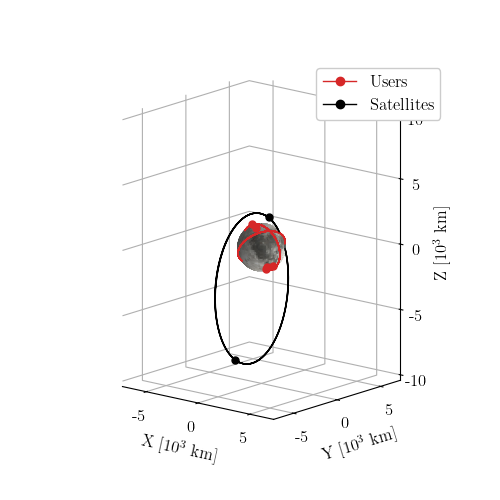

In [8]:
plt.rcParams.update({"font.size": 12})
fig = plotting.plot_satellites_users(
    rv_moon_sat_mi, rv_moon_user_mi, rv_moon_earth_mi, rv_moon_sun_mi, user_type, elev=15, azim=-50
)
plt.savefig(os.path.join(figures_path, "satellite_users.pdf"))
plt.show()

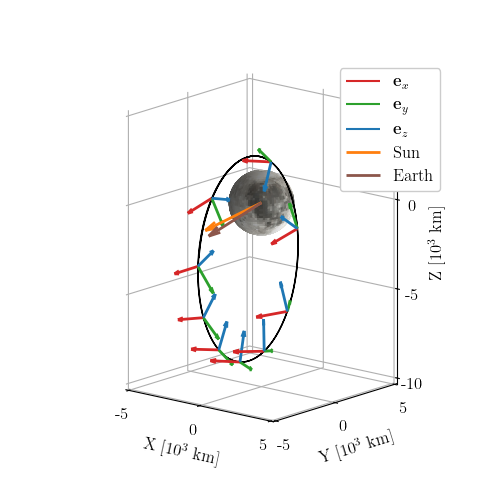

In [5]:
# Attitude
fig = pnt.plot.Plot3D(figsize=(5, 5), elev=15, azim=-50)
fig.plot_surface(pnt.MOON, scale=3)

i_sat = 0
plt.plot(
    rv_moon_sat_mi[i_sat, :, 0],
    rv_moon_sat_mi[i_sat, :, 1],
    rv_moon_sat_mi[i_sat, :, 2],
    color="black",
    linewidth=1,
)
e_moon_sun = rv_moon_sun_mi[0, 0:3] / np.linalg.norm(rv_moon_sun_mi[0, 0:3])
e_moon_earth = rv_moon_earth_mi[0, 0:3] / np.linalg.norm(rv_moon_earth_mi[0, 0:3])

# Yaw-Steering Frame
scale = pnt.R_MOON
for i in range(0, int(N_t / 2.3), 15):
    r_ys = rv_moon_sat_mi[i_sat, i, 0:3]
    plt.quiver(
        *r_ys,
        *ex_ys[i_sat, i] * scale,
        color="tab:red",
        arrow_length_ratio=0.2,
    linewidth=2,
    )
    plt.quiver(
        *r_ys,
        *ey_ys[i_sat, i] * scale,
        color="tab:green",
        arrow_length_ratio=0.2,
    linewidth=2,
    )
    plt.quiver(
        *r_ys,
        *ez_ys[i_sat, i] * scale,
        color="tab:blue",
        arrow_length_ratio=0.2,
    linewidth=2,
    )
plt.quiver([], [], [], [], [], [], color="tab:red", label="$\\mathbf{e}_x$")
plt.quiver([], [], [], [], [], [], color="tab:green", label="$\\mathbf{e}_y$")
plt.quiver([], [], [], [], [], [], color="tab:blue", label="$\\mathbf{e}_z$")


scale = 2 * pnt.R_MOON
plt.quiver(
    0,
    0,
    0,
    e_moon_sun[0] * scale,
    e_moon_sun[1] * scale,
    e_moon_sun[2] * scale,
    arrow_length_ratio=0.2,
    linewidth=2,
    color="tab:orange",
    label="Sun"
)
plt.quiver(
    0,
    0,
    0,
    e_moon_earth[0] * scale,
    e_moon_earth[1] * scale,
    e_moon_earth[2] * scale,
    linewidth=2,
    arrow_length_ratio=0.2,
    color="tab:brown",
    label="Earth"
)

fig.set_tickpad(0)
fig.set_tick_multiplier(1e-3)
fig.set_labels("X [$10^3$ km]", "Y [$10^3$ km]", "Z [$10^3$ km]")
fig.set_pane_color([1, 1, 1])
fig.set_labelpad(0, 0, 0)
fig.set_lims([-5e3, 5e3], [-5e3, 5e3], [-10e3, 5e3])
plt.legend(facecolor="white", framealpha=1, loc="upper right")

plt.savefig(os.path.join(figures_path, "satellite_attitude.pdf"))
plt.show()

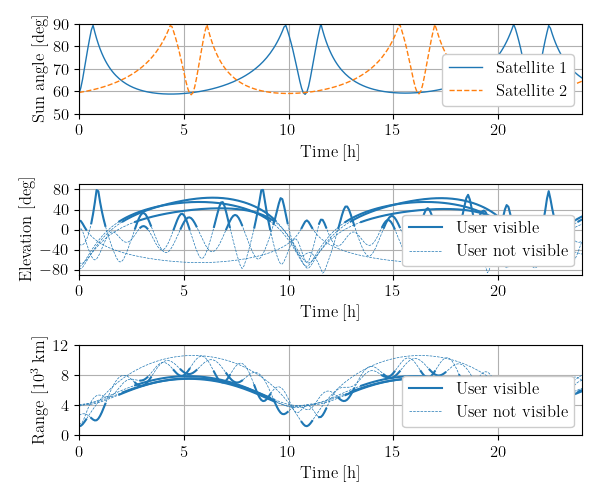

In [17]:
fig, axs = plt.subplots(3, 1, figsize=(6, 5))
# Sun pointing
plt.sca(axs[0])
sun_angle_cos = np.sum(e_sun * ex_ys, axis=2)
sun_angle = np.arccos(sun_angle_cos)
x = tspan / pnt.SECS_PER_HOUR
y = 90 - np.rad2deg(sun_angle)
plt.plot(x, y[0], label="Satellite 1", color="tab:blue", lw=1)
plt.plot(x, y[1], label="Satellite 2", color="tab:orange", linestyle="--", lw=1)

plt.ylabel("Sun angle [deg]")
plt.xlim([0, 24])
plt.ylim([50, 90])
plt.yticks(np.arange(50, 90 + 1, 10))
plt.xlabel("Time [h]")
plt.grid()
plt.legend(facecolor="white", framealpha=1, loc="lower right")
plt.tight_layout()

plotting.plot_elevation_range(tspan, az_el_rho[0], user_visible[0], axs=axs[1:])
axs[1].set_ylim([-90, 90])
axs[1].set_yticks(np.arange(-80, 80 + 1, 40))
axs[2].set_ylim([0, 11])
axs[2].set_yticks(np.arange(0, 13, 4))
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "satellite_sun_elevation_range.pdf"))
plt.show()

In [18]:
# Contact durations
contact_durations = list[np.array]([] for _ in range(N_sat))
contact_start_ends = list[np.array]([] for _ in range(N_sat))
for i_sat in range(N_sat):
    for i, user in enumerate(users):
        starts, ends = util.get_start_end_indexes(user_visible[i_sat, i])
        contact_start_ends[i_sat].append(np.vstack((starts, ends)).T)
        contact_durations[i_sat].append((ends - starts) * Dt / pnt.SECS_PER_MINUTE)
total_contact_durations = np.array([[x.sum() for x in contact_durations[i_sat]] for i_sat in range(N_sat)])
contact_durations_pathfinder = np.array([user["contact"] for user in users])

print("Contact durations [min]")
pp.pprint(contact_durations)
print("Total contact durations [min]")
pp.pprint(total_contact_durations)
print("Pathfinder contact durations [min]")
pp.pprint(contact_durations_pathfinder)

Contact durations [min]
[[array([45., 50., 50., 50., 45., 50., 50., 50., 50., 45.]),
  array([435., 440.,  30.]),
  array([400., 400.]),
  array([440., 440.,  15.]),
  array([ 5., 25., 50., 50., 50., 25., 40., 45., 50., 35.]),
  array([25., 35., 35.])],
 [array([50., 45., 50., 50., 50., 50., 45., 50., 50., 50.]),
  array([230., 435., 355.]),
  array([240., 400., 310.]),
  array([245., 440., 340.]),
  array([50., 50., 20., 30., 35., 45., 50., 40., 15., 45., 45.]),
  array([35., 35.])]]
Total contact durations [min]
array([[ 485.,  905.,  800.,  895.,  375.,   95.],
       [ 490., 1020.,  950., 1025.,  425.,   70.]])
Pathfinder contact durations [min]
array([150, 467, 529, 248, 100,  23])


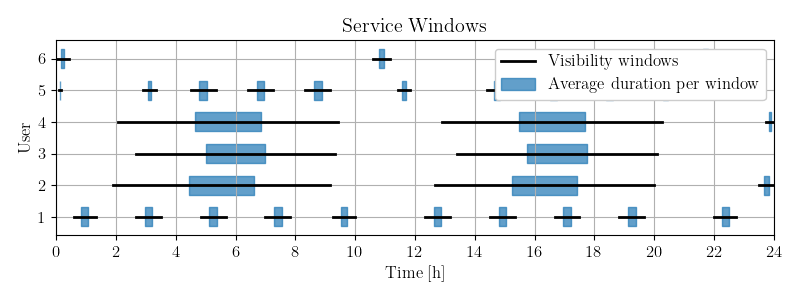

In [19]:
import matplotlib.pyplot as plt

duration_factor = 0.3
time_multiplier = Dt / pnt.SECS_PER_HOUR
plotting.plot_service_windows(contact_start_ends[0], duration_factor, time_multiplier)
plt.xlim(0, tf / pnt.SECS_PER_HOUR)
plt.xticks(np.arange(0, tf / pnt.SECS_PER_HOUR + 1, 2))
plt.tight_layout()
plt.show()

In [32]:
# Navigation signal
fs = 2492.028e6  # Carrier frequency [Hz]
fc = 5.115e6  # Spread code frequency [Hz]
Tc = 1 / fc  # Spread code period [s]

# Receiver parameters
NF_lna = 1  # LNA noise figure [dB]
T_sys = 113  # System noise temperature [K]
B_dll = 0.5  # DLL bandwidth [Hz]
d = 1.0  # Early-late spacing [chips]
T_i = 0.02  # Coherent integration time [s]
B_fe = 2 * fc  # Front-end bandwidth [Hz]

# Constants
c = 2.998e8  # Speed of light [m/s]
k = -228.6  # Boltzmann constant [dBW/Hz/K]

# Link budget
rv_user_sat_mi = rv_moon_user_mi[None, :, :, :] - rv_moon_sat_mi[:, None, :, :]
r = np.linalg.norm(rv_user_sat_mi[:, :, :, :3], axis=3)
r[~user_visible] = np.nan
# r = 8e6 # Distance [m]
EIRP = 30  # Equivalent isotropic radiated power [dBW]
L_fs = np.zeros_like(r)  # Free space loss [dB]
for i_sat in range(N_sat):
    L_fs[i_sat] = pnt.decimal2dB((4 * np.pi * r[i_sat] * fs / c) ** 2)  # Free space loss [dB]
L_fs = 10 * np.log10((4 * np.pi * r * fs / c) ** 2)  # Free space loss [dB]
Pr = EIRP - L_fs  # Received power [dBW]

# Antenna gain
T_atm = 290  # Atmospheric noise temperature [K]
T_eq = 10 * np.log10(
    T_sys + T_atm * (10 ** (NF_lna / 10) - 1)
)  # Equivalent noise temperature [dBK]

mu = 0.6  # Antenna efficiency
D_ant = 0.3  # Antenna diameter [m]
# Maximum antenna gain [dBi]
Gr_max = pnt.decimal2dB(mu * (np.pi * D_ant * fs / c) ** 2)
Gr_max = 6

theta = 0  # Beamwidth [deg]
theta_3dB = 40  # 3 dB beamwidth [deg]
Gr = pnt.decimal2dB(pnt.dB2decimal(Gr_max) - 12 * (theta / theta_3dB) ** 2)  # [dBi]

# Gain-to-noise temperature [dB]
GT = Gr - T_eq
# GT = -20
CN0 = Pr - k + GT  # Carrier-to-noise density ratio [dB-Hz]

# Error contributions
# Delay Lock Loop (DLL) error [m]
term_1 = (c * Tc) ** 2 * (B_dll * (1 - 0.5 * B_dll * T_i)) / (2 * CN0)
if d >= np.pi / (Tc * B_fe):
    sigma_p_dll_sq = term_1 * d
elif np.pi / (Tc * B_fe) > d > 1 / (Tc * B_fe):
    term_2 = (1 / (Tc * B_fe)) + ((Tc * B_fe) / (np.pi - 1)) * (
        d - (1 / (Tc * B_fe))
    ) ** 2
    term_3 = 1 + (2 / (T_i * CN0 * (2 - d)))
    sigma_p_dll_sq = term_1 * term_2 * term_3
else:  # d <= 1 / (T_c * B_fe)
    term_2 = 1 / (Tc * B_fe)
    term_3 = 1 + (1 / (T_i * CN0))
    sigma_p_dll_sq = term_1 * term_2 * term_3
sigma_p_dll = np.sqrt(sigma_p_dll_sq)

sigma_p_eph = 5  # Satellite ephemeris error [m]
sigma_p_rel = 0.31  # Residual relay delay error [m]
sigma_p_mul = 0.2  # Lunar multipath error [m]
sigma_p_non_eph = np.sqrt(sigma_p_dll**2 + sigma_p_rel**2 + sigma_p_mul**2)
sigma_p_tot = np.sqrt(4 * sigma_p_eph**2 + sigma_p_non_eph**2)

/var/folders/m9/t0lwgrj15w37pjv7jdy9m0g40000gp/T/ipykernel_12145/3756178462.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 2, figsize=(8, 4))


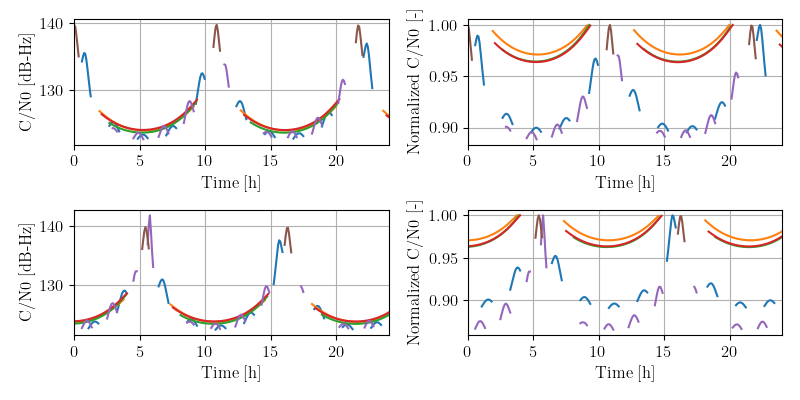

In [33]:
fig, ax = plt.subplots(2, 2, figsize=(8, 4))
x = tspan / pnt.SECS_PER_HOUR
plt.sca(ax[0,0])
plt.plot(x, CN0[0].T)
plt.xlabel("Time [h]")
plt.ylabel("C/N0 [dB-Hz]")
plt.xlim([x[0], x[-1]])
plt.grid()

plt.sca(ax[1,0])
plt.plot(x, CN0[1].T)
plt.xlabel("Time [h]")
plt.ylabel("C/N0 [dB-Hz]")
plt.xlim([x[0], x[-1]])
plt.grid()

plt.sca(ax[0,1])
CN0_norm = CN0[0].copy()
CN0_norm /= np.nanmax(CN0_norm, axis=1)[:, None]
plt.plot(x, CN0_norm.T)
plt.xlabel("Time [h]")
plt.ylabel("Normalized C/N0 [-]")
plt.xlim([x[0], x[-1]])
plt.grid()

plt.sca(ax[1,1])
CN0_norm = CN0[1].copy()
CN0_norm /= np.nanmax(CN0_norm, axis=1)[:, None]
plt.plot(x, CN0_norm.T)
plt.xlabel("Time [h]")
plt.ylabel("Normalized C/N0 [-]")
plt.xlim([x[0], x[-1]])
plt.grid()

plt.tight_layout()
plt.show()

In [34]:
# GDOP
i_sat = 0
user = 0
w = 10
s = 5
e = s + w
e_usr_sat = util.normalize(rv_user_sat_mi[i_sat, user, s:e, :3])
# G = np.hstack((e_usr_sat, np.ones((e_usr_sat.shape[0], 1))))
G = e_usr_sat
H = np.linalg.inv(G.T @ G)
gdop = np.sqrt(np.trace(H))
print(f"Duration {w * Dt / pnt.SECS_PER_HOUR:.2f} h")
print("PDOP", gdop)

Duration 0.83 h
PDOP 8.205954839195375


In [35]:
# Time in hours
duration_factor = 1

# Requests
requests = list[Request]()
requests.append(
    Request(
        id=-1,
        usr_id=-1,
        rv=None,
        start=0,
        end=tf / pnt.SECS_PER_HOUR,
        duration=tf / pnt.SECS_PER_HOUR,
        priority=0,
    ),  # Dummy request
)
resquest_id = 0
for i, user in enumerate(users):
    requests.append(
        Request(
            id=resquest_id,
            usr_id=user["id"],
            rv=rv_moon_user_mi[i],
            start=0,
            end=tf / pnt.SECS_PER_HOUR,
            duration=contact_durations_pathfinder[i]
            * pnt.SECS_PER_MINUTE
            / pnt.SECS_PER_HOUR
            * duration_factor,
        )
    )
    resquest_id += 1
N_req = len(requests)

# Service windows
service_windows = list[ServiceWindow]()
window_id = 0
for i_sat in range(N_sat):
    service_windows.append(
    ServiceWindow(
        id=-1,
        sat_id=i_sat,
        request_id=-1,
        start=0,
        end=tf / pnt.SECS_PER_HOUR,
    )  # Dummy service window
)
    for i, request in enumerate(requests[1:]):
        for start, end in contact_start_ends[i_sat][i]:
            service_windows.append(
                ServiceWindow(
                    id=window_id,
                    sat_id=i_sat,
                    request_id=request.id,
                    start=ceil(start * Dt / pnt.SECS_PER_HOUR * 10) / 10,
                    end=floor(end * Dt / pnt.SECS_PER_HOUR * 10) / 10,
                )
            )
            window_id += 1
N_win = len(service_windows)

# Transition times
transition_times = np.ones((N_sat, N_win, N_win))
transition_times *= 0.2  # hours
for i_sat in range(N_sat):
    np.fill_diagonal(transition_times[i_sat, :, :], 0)
    transition_times[i_sat, 0, :] = 0
    transition_times[i_sat, :, 0] = 0

# Energy and data generation functions
S_panels = 3 * 0.5 * 0.8  # [m^2] Solar panels area
I_earth = 1361  # [W/m^2] Solar irradiance
efficiency = 0.2  # Solar panels efficiency
P_solar_max = round(S_panels * I_earth * efficiency)  # [W] Max power generation
P_solar_max = 50  # [W] Max power generation
R_dte_max = -2e3  # [kbps] Direct-To-Earth max data rate

payload_data_gen = -1.9 * R_dte_max  # [kbps] Payload data generation
payload_energy_gen = -1.9 * P_solar_max  # [W] Payload power generation

max_energy = np.abs(P_solar_max) * 12  # [Wh] Max energy capacity
min_energy = max_energy * 0.2  # [Wh] Min energy capacity
max_data = np.abs(R_dte_max) * 12  # [Mb] Max data capacity
min_data = max_data * 0.2  # [Mb] Min data capacity


def energy_gen_func(ts, te):
    """
    Satellite energy generation function.
    :param ts: [h] Start time
    :param te: [h] End time
    :return: [Wh] Energy generation
    """

    if not isinstance(ts, np.ndarray):
        i_s = int(ts * pnt.SECS_PER_HOUR / Dt)
        i_e = int(te * pnt.SECS_PER_HOUR / Dt)
        if i_e == i_s:
            if i_e < len(sun_angle_cos):
                i_e += 1
            else:
                i_s -= 1
        return P_solar_max * np.mean(sun_angle_cos[0, i_s:i_e]) * (te - ts)
    else:
        energy = np.zeros(len(ts))
        for i in range(len(ts)):
            i_s = int(ts[i] * pnt.SECS_PER_HOUR / Dt)
            i_e = int(te[i] * pnt.SECS_PER_HOUR / Dt)
            if i_e == i_s:
                if i_e < len(sun_angle_cos):
                    i_e += 1
                else:
                    i_s -= 1
            energy[i] = P_solar_max * np.mean(sun_angle_cos[0, i_s:i_e]) * (te[i] - ts[i])
        return energy


def data_gen_func(ts, te):
    """
    Satellite data generation function (downlink).
    :param ts: [h] Start time
    :param te: [h] End time
    :return: [Mb] Data generation
    """
    return R_dte_max * (te - ts)


# Problem
problem = PntSchedulingProblem(
    time_step=Dt / pnt.SECS_PER_HOUR,
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    CN0=CN0,
    N_max_actions=10,
    min_action_duration=5,
    max_energy=max_energy,
    min_energy=min_energy,
    max_data=max_data,
    min_data=min_data,
    payload_data_gen=payload_data_gen,
    payload_energy_gen=payload_energy_gen,
    energy_gen_func=energy_gen_func,
    data_gen_func=data_gen_func,
)

gamma=0.7

def print_metrics(policy, gamma=1):
    # Metrics
    percentages = problem.percentage_completed(policy)
    percentage = problem.duration_fullfilled(policy)
    reward = problem.total_reward(policy, gamma=gamma)
    print("Percentage of requests served:")
    pp.pprint(percentages)
    print(round(percentage, 2), "%")
    print("Total reward:", round(reward, 2))

print("Durations")
durations = [round(r.duration, 2) for r in requests[1:]]
print([(i+1, d) for i, d in enumerate(durations)])
print("Total duration", round(sum(durations),2))

Durations
[(1, 2.5), (2, 7.78), (3, 8.82), (4, 4.13), (5, 1.67), (6, 0.38)]
Total duration 25.28


In [36]:
contact_durations_pathfinder

array([150, 467, 529, 248, 100,  23])

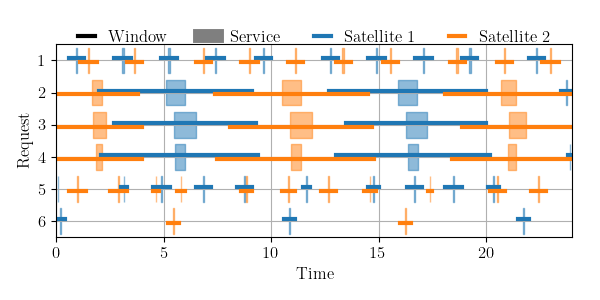

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)

In [38]:
import matplotlib.gridspec as gridspec
def plot_policy(policy):
    fig = plt.figure(tight_layout=True, figsize=(6, 6))
    gs = gridspec.GridSpec(4, 1)
    # plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
    ax = fig.add_subplot(gs[:2])
    plotting.plot_requests_service_windows(requests, service_windows, policy, ax=ax)
    ax1 = fig.add_subplot(gs[2])
    ax2 = fig.add_subplot(gs[3])
    plotting.plot_resources(problem, policy, ax=[ax1, ax2])

def print_policy(policy):
    pp.pprint({i: p for i, p in enumerate(policy)})

Elapsed time: 0.00 s
Percentage of requests served:
{0: 100.0, 1: 100.0, 2: 56.71, 3: 100.0, 4: 100.0, 5: 100.0}
84.9 %
Total reward: 20.55


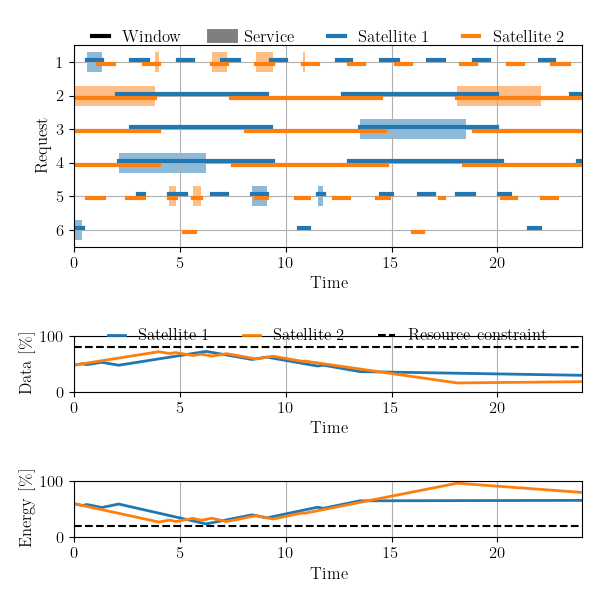

In [39]:
# Rule-based
solver = RuleBasedSolver(problem)
s = problem.initial_state()
elapsed_time = time.time()
policy_rb = solver.solve(s)
elapsed_time = time.time() - elapsed_time
print(f"Elapsed time: {elapsed_time:.2f} s")

print_metrics(policy_rb, gamma=1)
plot_policy(policy_rb)

In [40]:
# Forward search
np.random.seed(0)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
elapsed_time = time.time()
policy_fs = solver.solve(s, d=4, gamma=0.99)
elapsed_time = time.time() - elapsed_time
print(f"Elapsed time: {elapsed_time:.2f} s")

Solving Forward Search (progress in hours):   0%|          | 0/24 [00:00<?, ?it/s]

Elapsed time: 3.47 s


Percentage of requests served:
{0: 100.0, 1: 100.0, 2: 100.0, 3: 100.0, 4: 100.0, 5: 100.0}
100.0 %
Total reward: 24.27


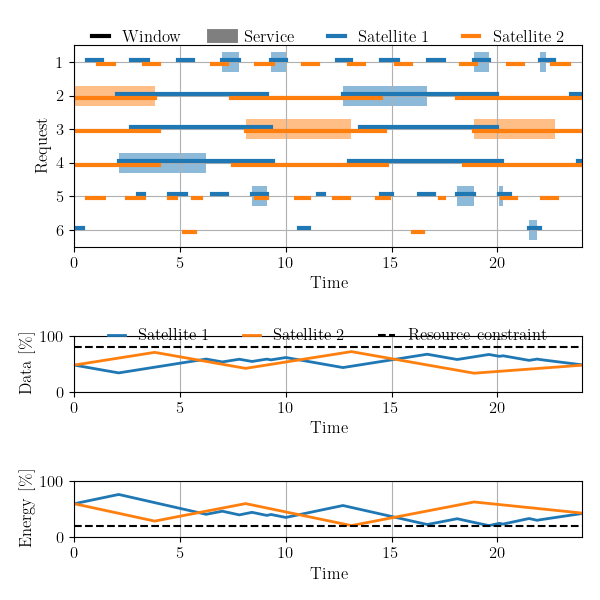

In [41]:
print_metrics(policy_fs, gamma=1)
plot_policy(policy_fs)

In [42]:
# MCTS
np.random.seed(0)
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
elapsed_time = time.time()
policy_mcts = solver.solve(s, d=20, gamma=0.99, n=int(200), c=10)
elapsed_time = time.time() - elapsed_time
print(f"Elapsed time: {elapsed_time:.2f} s")


Solving MCTS (progress in hours):   0%|          | 0/24 [00:00<?, ?it/s]

Elapsed time: 2.03 s


Percentage of requests served:
{0: 100.0, 1: 100.0, 2: 100.0, 3: 100.0, 4: 100.0, 5: 100.0}
100.0 %
Total reward: 24.21


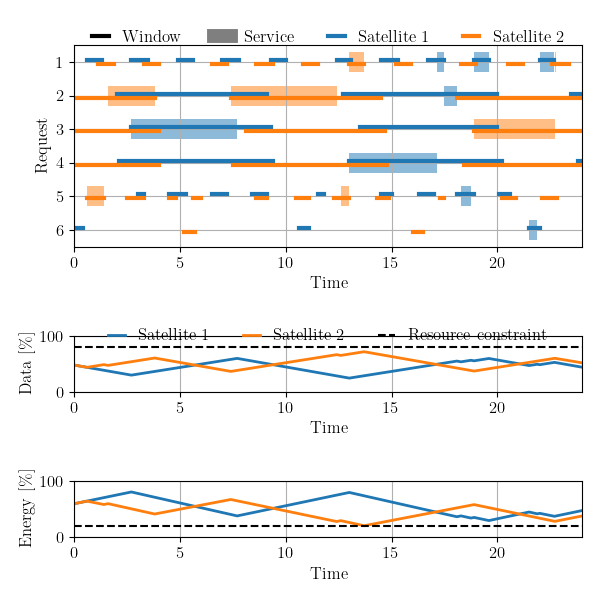

In [43]:
print_metrics(policy_mcts, gamma=1)
plot_policy(policy_mcts)
plt.show()

In [44]:
# IP
np.random.seed(0)
solver = DiscreteTimeIpSolver(problem)
elapsed_time = time.time()
policy_ip = solver.solve(s, time_step_factor=1)
elapsed_time = time.time() - elapsed_time
print(f"Elapsed time: {elapsed_time:.2f} s")

Service window 18 has duration 0. Try decreasing time step.
                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Apr 04 02:42:11 PM: Your problem has 4032 variables, 26993 constraints, and 0 parameters.
(CVXPY) Apr 04 02:42:12 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 04 02:42:12 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 04 02:42:12 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 04 02:42:12 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY

Percentage of requests served:
{0: 100.0, 1: 100.0, 2: 100.0, 3: 100.0, 4: 100.0, 5: 100.0}
100.0 %
Total reward: 25.08


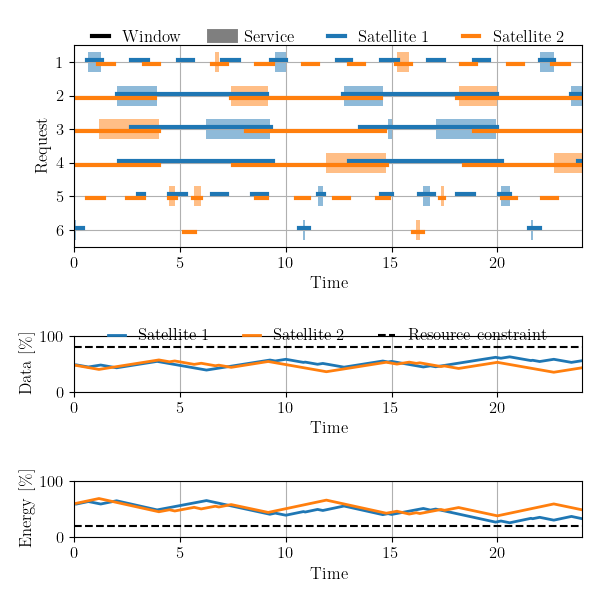

In [50]:
print_metrics(policy_ip, gamma=1)
plot_policy(policy_ip)

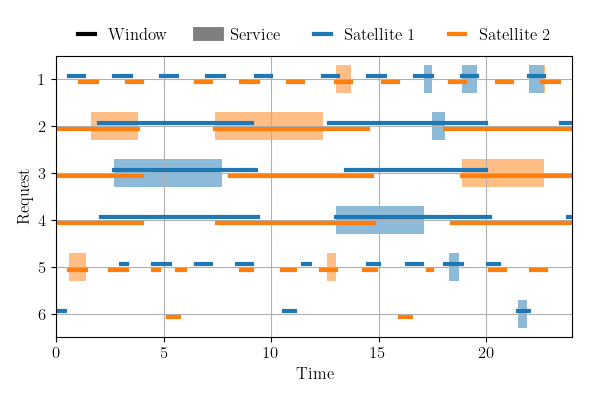

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plotting.plot_requests_service_windows(requests, service_windows, policy_mcts, ax=ax)
plt.savefig(os.path.join(figures_path, "policy_mcts.pdf"))
plt.show()

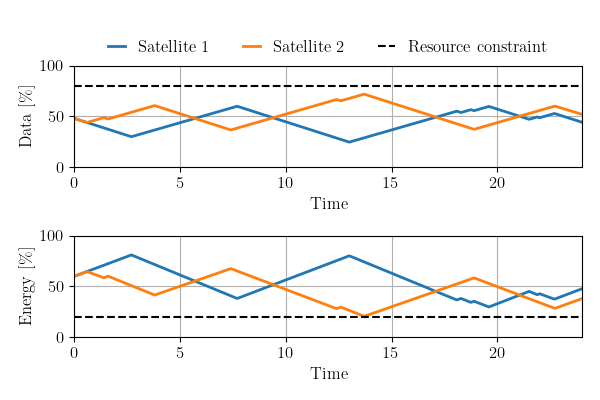

In [47]:
fig, axs = plt.subplots(2, 1, figsize=(6, 4))
plotting.plot_resources(problem, policy_mcts, ax=axs)
plt.savefig(os.path.join(figures_path, "resources_mcts.pdf"))
plt.show()

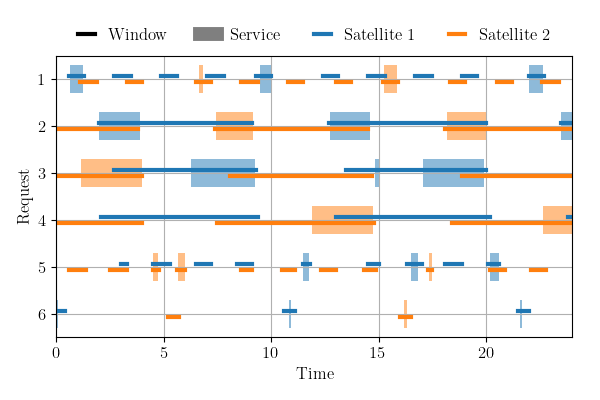

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plotting.plot_requests_service_windows(requests, service_windows, policy_ip, ax=ax)
plt.savefig(os.path.join(figures_path, "policy_ip.pdf"))
plt.show()

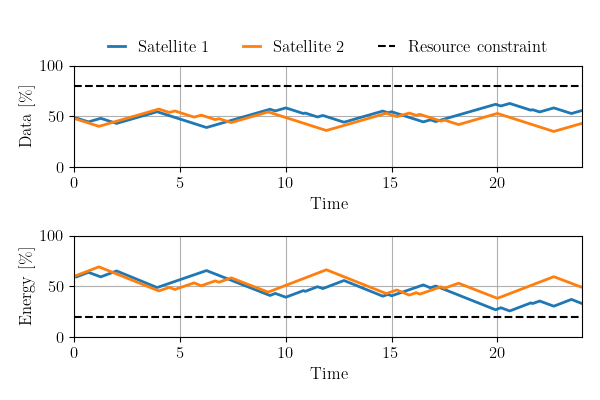

In [49]:
fig, axs = plt.subplots(2, 1, figsize=(6, 4))
plotting.plot_resources(problem, policy_ip, ax=axs)
plt.savefig(os.path.join(figures_path, "resources_ip.pdf"))
plt.show()